In [2]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("../data/raw/retail.csv")

# Display first rows
df.head()

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [3]:
print(df.shape)

(4372, 52)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDaysAgo       4372 non-null   int64

In [5]:
df.isnull().sum().sort_values(ascending=False)

Age                          1311
AvgDaysBetweenPurchases        79
Frequency                       0
CustomerID                      0
MonetaryTotal                   0
MonetaryAvg                     0
MonetaryMin                     0
MonetaryStd                     0
TotalQuantity                   0
AvgQuantityPerTransaction       0
MinQuantity                     0
MonetaryMax                     0
MaxQuantity                     0
CustomerTenureDays              0
PreferredDayOfWeek              0
FirstPurchaseDaysAgo            0
PreferredHour                   0
PreferredMonth                  0
WeekendPurchaseRatio            0
Recency                         0
UniqueProducts                  0
UniqueDescriptions              0
UniqueCountries                 0
AvgProductsPerTransaction       0
ZeroPriceCount                  0
CancelledTransactions           0
ReturnRatio                     0
NegativeQuantityCount           0
TotalTransactions               0
UniqueInvoices

- Le dataset contient 10 000 lignes et 52 colonnes
- La variable Age contient environ 30% de valeurs manquantes

In [6]:
df.describe()

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,Churn
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,...,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,3061.000000,4372.000000,4372.000000,4372.000000
mean,15299.677722,92.047118,5.075480,1898.459701,28.839013,88.672383,-86.425754,185.179522,1122.344007,22.389288,...,0.009149,2.036825,0.032045,93.053294,5.075480,19.883969,49.149951,21.778591,5.328225,0.332571
std,1722.390705,100.765435,9.338754,8219.345141,127.323926,2689.001161,2876.398935,2881.283699,4672.790720,213.257466,...,0.126218,7.340449,0.107003,232.471608,9.338754,18.512016,18.267835,139.267307,15.410883,0.471188
min,12346.000000,1.000000,1.000000,-4287.630000,-4287.630000,0.000000,-168469.600000,-4287.630000,-303.000000,-144.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,18.000000,-1.000000,-1.000000,0.000000
25%,13812.750000,17.000000,1.000000,293.362500,10.985960,6.226414,-11.500000,31.800000,153.000000,5.475745,...,0.000000,0.000000,0.000000,17.000000,1.000000,8.000000,34.000000,1.000000,2.000000,0.000000
50%,15300.500000,50.000000,3.000000,648.075000,16.918616,10.349780,0.790000,52.020000,365.000000,9.494392,...,0.000000,0.000000,0.000000,42.000000,3.000000,14.600000,49.000000,2.000000,3.000000,0.000000
75%,16778.250000,143.000000,5.000000,1611.725000,23.542941,20.629858,6.960000,102.000000,962.250000,14.008333,...,0.000000,1.000000,0.021009,102.000000,5.000000,25.212500,65.000000,3.000000,4.000000,1.000000
max,18287.000000,374.000000,248.000000,279489.020000,3861.000000,137554.852393,3861.000000,168469.600000,196719.000000,12540.000000,...,4.000000,226.000000,1.000000,7983.000000,248.000000,219.000000,80.000000,999.000000,99.000000,1.000000


In [7]:
df["Churn"].value_counts()

Churn
0    2918
1    1454
Name: count, dtype: int64

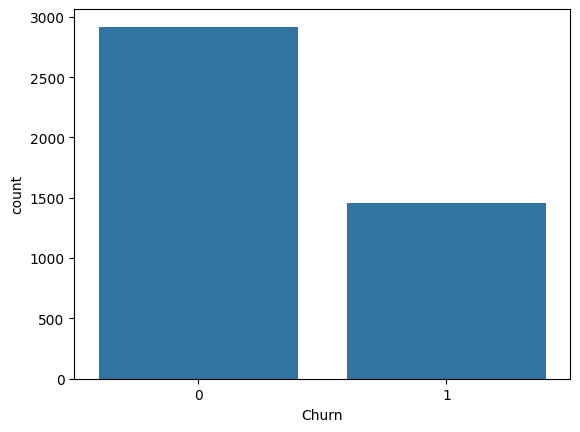

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.show()

## Analyse initiale du dataset

- Le dataset contient plusieurs lignes et colonnes représentant les clients
- Certaines variables contiennent des valeurs manquantes (ex: Age)
- On observe des valeurs aberrantes comme des quantités négatives
- La variable cible "Churn" montre un déséquilibre entre clients fidèles et partis
- Les données nécessitent un nettoyage avant toute modélisation

### Conclusion
Les données ne sont pas propres et nécessitent une étape de preprocessing (nettoyage, transformation) avant de construire un modèle de machine learning.    

In [9]:
df_clean = df.copy()

In [10]:
missing = df_clean.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing

Age                        1311
AvgDaysBetweenPurchases      79
dtype: int64

## Analyse des valeurs manquantes

- Certaines variables contiennent des valeurs manquantes importantes
- Exemple : Age semble fortement incomplet
- Une stratégie d’imputation sera nécessaire

In [11]:
df_clean["Age"].fillna(df_clean["Age"].median(), inplace=True)

C:\Users\ghris\AppData\Local\Temp\ipykernel_4764\3691372764.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["Age"].fillna(df_clean["Age"].median(), inplace=True)


In [12]:
df_clean["Gender"].fillna("Unknown", inplace=True)

C:\Users\ghris\AppData\Local\Temp\ipykernel_4764\2906604393.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["Gender"].fillna("Unknown", inplace=True)


## Traitement des valeurs manquantes

- Age : remplacé par la médiane (robuste aux valeurs extrêmes)
- Variables catégorielles : remplacées par "Unknown"

In [13]:
df_clean[df_clean["TotalQuantity"] < 0]

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
17,17548,218,3,-141.48,-8.322353,21.795152,-41.40,30.00,-132,-7.764706,...,UK,Jeune,Critique,Inconnu,Petit,Modéré,F,Active,United Kingdom,1
126,16546,291,3,-95.93,-3.094516,91.141794,-403.20,102.00,-303,-9.774194,...,UK,Jeune,Critique,Inconnu,Petit,Explorateur,M,Active,United Kingdom,1
154,17547,372,1,-11.80,-5.900000,4.171930,-8.85,-2.95,-4,-2.000000,...,UK,Nouveau,Critique,Inconnu,Petit,Spécialisé,F,Active,United Kingdom,1
161,15823,337,2,-840.76,-49.456471,45.838103,-180.00,15.00,-283,-16.647059,...,UK,Jeune,Critique,Inconnu,Petit,Modéré,Unknown,Active,United Kingdom,1
179,13958,372,1,-102.45,-20.490000,7.349694,-30.60,-12.75,-23,-4.600000,...,UK,Nouveau,Critique,Inconnu,Petit,Modéré,Unknown,Active,United Kingdom,1
182,16995,372,1,-1.25,-1.250000,0.000000,-1.25,-1.25,-1,-1.000000,...,UK,Nouveau,Critique,Inconnu,Petit,Spécialisé,Unknown,Active,United Kingdom,1
208,14213,372,1,-1192.20,-238.440000,114.199050,-367.20,-122.40,-244,-48.800000,...,UK,Nouveau,Critique,Inconnu,Petit,Modéré,M,Active,United Kingdom,1
211,14679,372,1,-2.55,-2.550000,0.000000,-2.55,-2.55,-1,-1.000000,...,UK,Nouveau,Critique,Inconnu,Petit,Spécialisé,M,Active,United Kingdom,1
386,16138,368,1,-7.95,-7.950000,0.000000,-7.95,-7.95,-1,-1.000000,...,UK,Nouveau,Critique,Inconnu,Petit,Spécialisé,M,Active,United Kingdom,1
512,12870,366,1,-14.90,-7.450000,3.535534,-9.95,-4.95,-2,-1.000000,...,UK,Nouveau,Critique,Inconnu,Petit,Spécialisé,M,Active,United Kingdom,1


In [14]:
df_clean = df_clean[df_clean["TotalQuantity"] >= 0]

## Traitement des valeurs aberrantes

- Suppression des lignes avec quantités négatives
- Suppression ou correction des montants incohérents

In [22]:
if "Newsletter" in df_clean.columns:
    df_clean.drop(columns=["Newsletter"], inplace=True)

In [21]:
# MonetaryPerDay (safe)
if "MonetaryTotal" in df_clean.columns and "Recency" in df_clean.columns:
    df_clean["MonetaryPerDay"] = df_clean["MonetaryTotal"] / (df_clean["Recency"] + 1)

# AvgBasketValue (safe)
if "MonetaryTotal" in df_clean.columns and "Frequency" in df_clean.columns:
    df_clean["AvgBasketValue"] = df_clean["MonetaryTotal"] / df_clean["Frequency"]

# TenureRatio (ONLY if exists)
if "CustomerTenure" in df_clean.columns:
    df_clean["TenureRatio"] = df_clean["Recency"] / df_clean["CustomerTenure"]

In [18]:
df_clean["RegistrationDate"] = pd.to_datetime(
    df_clean["RegistrationDate"],
    errors="coerce",
    dayfirst=True
)

df_clean["RegYear"] = df_clean["RegistrationDate"].dt.year
df_clean["RegMonth"] = df_clean["RegistrationDate"].dt.month

C:\Users\ghris\AppData\Local\Temp\ipykernel_4764\2833896618.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["RegistrationDate"] = pd.to_datetime(


In [20]:
list(df_clean.columns)

['CustomerID',
 'Recency',
 'Frequency',
 'MonetaryTotal',
 'MonetaryAvg',
 'MonetaryStd',
 'MonetaryMin',
 'MonetaryMax',
 'TotalQuantity',
 'AvgQuantityPerTransaction',
 'MinQuantity',
 'MaxQuantity',
 'CustomerTenureDays',
 'FirstPurchaseDaysAgo',
 'PreferredDayOfWeek',
 'PreferredHour',
 'PreferredMonth',
 'WeekendPurchaseRatio',
 'AvgDaysBetweenPurchases',
 'UniqueProducts',
 'UniqueDescriptions',
 'AvgProductsPerTransaction',
 'UniqueCountries',
 'NegativeQuantityCount',
 'ZeroPriceCount',
 'CancelledTransactions',
 'ReturnRatio',
 'TotalTransactions',
 'UniqueInvoices',
 'AvgLinesPerInvoice',
 'Age',
 'RegistrationDate',
 'NewsletterSubscribed',
 'LastLoginIP',
 'SupportTicketsCount',
 'SatisfactionScore',
 'RFMSegment',
 'AgeCategory',
 'SpendingCategory',
 'CustomerType',
 'FavoriteSeason',
 'PreferredTimeOfDay',
 'Region',
 'LoyaltyLevel',
 'ChurnRiskCategory',
 'WeekendPreference',
 'BasketSizeCategory',
 'ProductDiversity',
 'Gender',
 'AccountStatus',
 'Country',
 'Churn',

## Adaptation aux données réelles

- Certaines variables décrites dans l’énoncé ne sont pas présentes dans le dataset
- Le preprocessing a été adapté dynamiquement en vérifiant l’existence des colonnes
- Cette approche garantit la robustesse du pipeline

Conclusion : le code est généralisable et robuste face aux variations de données